# Notebook 04 — CARMA Lévy increment recovery

Lévy increment recovery from the CARMA(4,3) model calibrated in notebook 02 (Kr=2, Kc=1).

**Model:** `dX = A*X dt + ep*sigma dL(t)`,  `Y_t = b^T X_t`

**Inputs:** `data/seasonality/french_panel.csv`, `data/kalman/price_multiscale_carma_selected.json`

**Outputs:** `data/levy/price_carma_levy_eigen1.json`, `data/levy/price_carma_levy_eigen2.json`

## 0. Data and state-space setup

Loads hourly log-price residuals and reconstructs the state-space from notebook 02.
Computes stationary covariance `P_norm` (Lyapunov, sigma=1), matrix exponential `eAh`,
Kalman filter state `X_f`, and eigendecomposition of `A` for the BDY recovery formula.

In [1]:
library(jsonlite)
library(expm)
library(GeneralizedHyperbolic)

df <- read.csv('../data/seasonality/french_panel.csv', row.names=1)
y  <- as.numeric(df[['log_price_resid']])
y  <- y[is.finite(y)]
y  <- y - mean(y)
n  <- length(y); h <- 1.0
cat(sprintf('n = %d   sd(y) = %.6f\n', n, sd(y)))

Le chargement a nécessité le package : Matrix


Attachement du package : 'expm'


L'objet suivant est masqué depuis 'package:Matrix':

    expm


Warning message:
"le package 'GeneralizedHyperbolic' a été compilé avec la version R 4.5.3"


n = 17521   sd(y) = 0.028280


In [2]:
ms    <- fromJSON('../data/kalman/price_multiscale_carma_selected.json')
ar    <- as.numeric(ms$ar_coefficients)
p     <- length(ar)
b_pen <- as.numeric(ms$b_coefficients)
sigma <- ms$sigma

A_fix <- matrix(0, p, p)
for (i in seq_len(p-1)) A_fix[i, i+1] <- 1.0
A_fix[p, ] <- -rev(ar)
ep    <- rep(0, p); ep[p] <- 1.0
eAh   <- expm(A_fix * h)

ev_fix   <- eigen(A_fix)
V        <- ev_fix$vectors
d        <- ev_fix$values
Vi       <- solve(V)
RHS      <- -(Vi %*% (ep %o% ep) %*% Conj(t(Vi)))
P_norm   <- Re(V %*% (RHS / outer(d, Conj(d), "+")) %*% Conj(t(V)))
Rinv_fix <- Vi

S_norm <- as.numeric(t(b_pen) %*% P_norm %*% b_pen)
K_stat <- as.numeric(P_norm %*% b_pen) / S_norm
X_f    <- matrix(0, n, p)
for (i in 2:n) {
  xp       <- as.numeric(eAh %*% X_f[i-1, ])
  inn      <- y[i] - sum(b_pen * xp)
  X_f[i, ] <- xp + K_stat * inn
}

n_real <- sum(abs(Im(ev_fix$values)) < 1e-6)
re_lam <- sort(Re(ev_fix$values[abs(Im(ev_fix$values)) < 1e-6]))
cat(sprintf('p=%d  sigma=%.4e  P_norm min_eig=%.3e\n',
            p, sigma, min(eigen(P_norm, only.values=TRUE)$values)))
cat(sprintf('Kalman done  X_f[n,] = [%s]\n',
            paste(sprintf('%.3e', X_f[n,]), collapse=', ')))
cat(sprintf('Real eigenvalues (%d):\n', n_real))
for (i in seq_along(re_lam))
  cat(sprintf('  lambda_%d = %+.4e h^-1   hl = %.2f h  (%.2f days)\n',
              i, re_lam[i], log(2)/abs(re_lam[i]), log(2)/abs(re_lam[i])/24))

Kalman done  X_f[n,] = [-1.252e+02, 3.693e-01, 1.079e-01, -8.643e-03]
Real eigenvalues (2):
  lambda_1 = -2.4356e-02 h^-1   hl = 28.46 h  (1.19 days)
  lambda_2 = -2.4460e-04 h^-1   hl = 2833.80 h  (118.08 days)


In [3]:
levy_recover_r <- function(which_real, ev, Rinv, Xf, b, ar, p, h_step=1.0) {
  evals  <- ev$values
  is_re  <- abs(Im(evals)) < 1e-6
  re_lam <- sort(Re(evals[is_re]))
  lam    <- re_lam[which_real]
  idx    <- which(abs(Im(evals)) < 1e-6 & abs(Re(evals) - lam) < 1e-8)[1]
  b_lam  <- sum(b * lam^(0:(p-1)))
  ap_lam <- sum(sapply(0:(p-1), function(k) (p-k)*c(1,ar)[k+1]*lam^(p-k-1)))
  alpha  <- Re(b_lam / ap_lam)
  Yr     <- Re(b_lam * as.numeric(Rinv[idx, ] %*% t(Xf)))
  nn     <- length(Yr)
  dL     <- numeric(nn-1)
  for (i in 2:nn)
    dL[i-1] <- (Yr[i]-Yr[i-1] - lam*0.5*(Yr[i]+Yr[i-1])*h_step) / alpha
  dL <- dL[is.finite(dL)]
  list(dL=dL, lambda_r=lam, alpha_r=alpha, b_lambda=Re(b_lam), ap_lambda=Re(ap_lam))
}

rinvgauss_fn <- function(n, mu, lam) {
  c2 <- lam/mu; nv <- rnorm(n)^2
  x  <- 1 + nv/(2*c2) - sqrt(nv/c2 + (nv/(2*c2))^2)
  ifelse(runif(n) <= 1/(1+x), x, 1/x) * mu
}

rnig_fn <- function(n, mu, delta, alpha, beta) {
  gam <- sqrt(alpha^2 - beta^2)
  V   <- rinvgauss_fn(n, delta/gam, delta^2)
  mu + beta*V + sqrt(V)*rnorm(n)
}

log_dnig_fn <- function(x, mu, delta, alpha, beta) {
  gam <- sqrt(alpha^2 - beta^2)
  r   <- sqrt(delta^2 + (x-mu)^2)
  log(alpha*delta/pi) + delta*gam + beta*(x-mu) +
    log(besselK(alpha*r, nu=1, expon.scaled=TRUE)) - alpha*r - log(r)
}

nig_fit_fn <- function(z) {
  mu_g <- mean(z); sig_g <- sd(z)
  ku   <- pmax(mean((z-mu_g)^4)/sig_g^4, 3.01)
  sk   <- mean((z-mu_g)^3)/sig_g^3
  a0   <- sqrt(3/(sig_g^2*(ku-3)))
  d0   <- sig_g^2 * a0
  b0   <- pmax(pmin(sk*a0*sqrt(d0*a0)/3, a0*0.9), -a0*0.9)
  th0  <- c(mu_g, log(d0), log(a0), atanh(b0/(a0*0.99)))
  nll  <- function(par) {
    mu_p    <- par[1]; delta_p <- exp(par[2])
    alpha_p <- exp(par[3]); beta_p <- tanh(par[4])*alpha_p*0.99
    lls <- tryCatch(log_dnig_fn(z, mu_p, delta_p, alpha_p, beta_p),
                    error=function(e) rep(-1e15, length(z)))
    if (any(!is.finite(lls))) return(1e15)
    -sum(lls)
  }
  best <- NULL
  for (s in seq(-1.5, 1.5, by=0.5)) {
    o <- tryCatch(nlminb(th0+c(0,0,0,s), nll,
                         control=list(iter.max=5000, rel.tol=1e-12)),
                  error=function(e) NULL)
    if (!is.null(o) && is.finite(o$objective) &&
        (is.null(best) || o$objective < best$objective)) best <- o
  }
  if (is.null(best)) return(NULL)
  list(mu=best$par[1], delta=exp(best$par[2]),
       alpha=exp(best$par[3]),
       beta=tanh(best$par[4])*exp(best$par[3])*0.99,
       loglik=-best$objective)
}

cat('Helper functions ready: levy_recover_r, rnig_fn, nig_fit_fn\n')

Helper functions ready: levy_recover_r, rnig_fn, nig_fit_fn


## 1. Lévy increment recovery — eigenvalue 1 (fastest)

BDY (2011) formula for the **first real eigenvalue** `lambda_1` (most negative, fastest mean reversion).

```
dL_n = (1/alpha_r) [ Y^(r)(n) - Y^(r)(n-1) - lambda_r * h/2 * (Y^(r)(n) + Y^(r)(n-1)) ]
```

where `Y^(r)(t) = b(lambda_r) * [R^{-1} X(t)]_r` and `alpha_r = b(lambda_r) / a'(lambda_r)`.

Normalised increments `dL_true = dL / sigma` are fitted with Gaussian and NIG.
Results saved to `data/levy/price_carma_levy_eigen1.json`.

In [4]:
res_1 <- levy_recover_r(1, ev_fix, Rinv_fix, X_f, b_pen, ar, p)
dL_1  <- res_1$dL
dLt_1 <- dL_1 / sigma

cat(sprintf('=== Eigenvalue 1 (fastest) ===\n'))
cat(sprintf('  lambda_1  = %+.6e h^-1\n', res_1$lambda_r))
cat(sprintf('  half-life = %.2f h  (%.3f days)\n',
            log(2)/abs(res_1$lambda_r), log(2)/abs(res_1$lambda_r)/24))
cat(sprintf('  alpha_r   = %.6e\n', res_1$alpha_r))
cat(sprintf('  N(dL_1)   = %d\n', length(dL_1)))
cat(sprintf('  mean(dLt) = %.4e\n', mean(dLt_1)))
cat(sprintf('  sd(dLt)   = %.4e\n', sd(dLt_1)))
cat(sprintf('  skewness  = %+.4f\n', mean((dLt_1-mean(dLt_1))^3)/sd(dLt_1)^3))
cat(sprintf('  kurtosis  =  %.4f\n', mean((dLt_1-mean(dLt_1))^4)/sd(dLt_1)^4))

Warning message in levy_recover_r(1, ev_fix, Rinv_fix, X_f, b_pen, ar, p):
"les parties imaginaires sont perdues lors de la conversion automatique"


=== Eigenvalue 1 (fastest) ===
  lambda_1  = -2.435636e-02 h^-1
  half-life = 28.46 h  (1.186 days)
  alpha_r   = 9.057817e-01
  N(dL_1)   = 17520
  mean(dLt) = NaN
  sd(dLt)   = NA
  skewness  = NaN
  kurtosis  =  NaN


In [5]:
options(repr.plot.width=13, repr.plot.height=4)
par(mfrow=c(1,3), mar=c(4,4,3,1))

xr1 <- quantile(dLt_1, c(0.001, 0.999))
xg1 <- seq(xr1[1], xr1[2], length.out=500)
hist(dLt_1, breaks=200, freq=FALSE, col='#4472c4', border='white',
     main='dL_1 / sigma', xlab='dL_1 / sigma', xlim=xr1)
lines(xg1, dnorm(xg1, mean(dLt_1), sd(dLt_1)), col='red', lwd=2)

qqnorm(dLt_1, pch=16, cex=0.3, col='#4472c4', main='QQ vs Normal (eigenvalue 1)')
qqline(dLt_1, col='red', lwd=2)

acf(dLt_1, lag.max=48, main='ACF dL_1/sigma (should be ~0)')
par(mfrow=c(1,1))

ERROR: Error in seq.default(xr1[1], xr1[2], length.out = 500): 'from' doit être un nombre fini


In [6]:
mu_g1  <- mean(dLt_1); sig_g1 <- sd(dLt_1)
ll_g1  <- sum(dnorm(dLt_1, mu_g1, sig_g1, log=TRUE))
aic_g1 <- -2*ll_g1 + 2*2
cat(sprintf('Gaussian:  mu=%.4e  sigma=%.4e  loglik=%.2f  AIC=%.2f\n',
            mu_g1, sig_g1, ll_g1, aic_g1))

nig1   <- nig_fit_fn(dLt_1)
ll_n1  <- nig1$loglik; aic_n1 <- -2*ll_n1 + 2*4
gam_n1 <- sqrt(nig1$alpha^2 - nig1$beta^2)
cat(sprintf('NIG:  mu=%.4e  delta=%.4e  alpha=%.4e  beta=%.4e\n',
            nig1$mu, nig1$delta, nig1$alpha, nig1$beta))
cat(sprintf('NIG:  loglik=%.2f  AIC=%.2f  dAIC(NIG-Gauss)=%.2f\n',
            ll_n1, aic_n1, aic_n1-aic_g1))
cat(sprintf('NIG:  fitted sd=%.4e  fitted skew=%.4f\n',
            sqrt(nig1$delta*nig1$alpha^2/gam_n1^3),
            3*nig1$beta/(nig1$alpha*sqrt(nig1$delta*gam_n1))))

options(repr.plot.width=10, repr.plot.height=4)
xr1 <- quantile(dLt_1, c(0.001, 0.999))
xg1 <- seq(xr1[1], xr1[2], length.out=500)
par(mfrow=c(1,2), mar=c(4,4,3,1))
hist(dLt_1, breaks=200, freq=FALSE, col='#aec6e8', border='white',
     main='Gaussian vs NIG fit (eigenvalue 1)', xlab='dL_1 / sigma', xlim=xr1)
lines(xg1, dnorm(xg1, mu_g1, sig_g1), col='red', lwd=2)
lines(xg1, exp(log_dnig_fn(xg1, nig1$mu, nig1$delta, nig1$alpha, nig1$beta)),
      col='darkgreen', lwd=2)
legend('topright', c('Gaussian','NIG'), col=c('red','darkgreen'), lwd=2, bty='n')
set.seed(1)
prbs   <- ppoints(length(dLt_1))
q_nig1 <- quantile(rnig_fn(length(dLt_1)*5, nig1$mu, nig1$delta,
                             nig1$alpha, nig1$beta), prbs)
plot(q_nig1, sort(dLt_1), pch=16, cex=0.25, col='#4472c4',
     main='QQ: empirical vs NIG (eigenvalue 1)',
     xlab='NIG quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)
par(mfrow=c(1,1))

write(toJSON(list(
  eigenvalue_idx = 1L,
  lambda_r       = res_1$lambda_r,
  alpha_r        = res_1$alpha_r,
  sigma          = sigma,
  n_increments   = length(dLt_1),
  dL_true        = as.list(dLt_1),
  gaussian       = list(mu=mu_g1, sigma=sig_g1, loglik=ll_g1, AIC=aic_g1),
  nig            = list(mu=nig1$mu, delta=nig1$delta, alpha=nig1$alpha,
                        beta=nig1$beta, loglik=ll_n1, AIC=aic_n1),
  note = 'dL_true = dL_BDY / sigma. Simulate: X[n] = eAh*X[n-1] + ep*sigma*dL_true_sim'
), auto_unbox=TRUE, digits=15),
'../data/levy/price_carma_levy_eigen1.json')
cat('Saved: data/levy/price_carma_levy_eigen1.json\n')

Gaussian:  mu=NaN  sigma=NA  loglik=0.00  AIC=4.00
NIG:  mu=NaN  delta=NA  alpha=NA  beta=NA
NIG:  loglik=0.00  AIC=8.00  dAIC(NIG-Gauss)=4.00
NIG:  fitted sd=NA  fitted skew=NA


ERROR: Error in seq.default(xr1[1], xr1[2], length.out = 500): 'from' doit être un nombre fini


## 2. Lévy increment recovery — eigenvalue 2 (slowest)

BDY (2011) formula for the **second real eigenvalue** `lambda_2` (least negative, slowest mean reversion).

The slowest eigenvalue minimises the trapezoid discretisation error O(h^2 * lambda_r^2),
making it the most accurate BDY estimator.

Results saved to `data/levy/price_carma_levy_eigen2.json`.

In [24]:
res_2 <- levy_recover_r(2, ev_fix, Rinv_fix, X_f, b_pen, ar, p)
dL_2  <- res_2$dL
dLt_2 <- dL_2 / sigma

cat(sprintf('=== Eigenvalue 2 (slowest) ===\n'))
cat(sprintf('  lambda_2  = %+.6e h^-1\n', res_2$lambda_r))
cat(sprintf('  half-life = %.2f h  (%.3f days)\n',
            log(2)/abs(res_2$lambda_r), log(2)/abs(res_2$lambda_r)/24))
cat(sprintf('  alpha_r   = %.6e\n', res_2$alpha_r))
cat(sprintf('  N(dL_2)   = %d\n', length(dL_2)))
cat(sprintf('  mean(dLt) = %.4e\n', mean(dLt_2)))
cat(sprintf('  sd(dLt)   = %.4e\n', sd(dLt_2)))
cat(sprintf('  skewness  = %+.4f\n', mean((dLt_2-mean(dLt_2))^3)/sd(dLt_2)^3))
cat(sprintf('  kurtosis  =  %.4f\n', mean((dLt_2-mean(dLt_2))^4)/sd(dLt_2)^4))

Warning message in levy_recover_r(2, ev_fix, Rinv_fix, X_f, b_pen, ar, p):
"les parties imaginaires sont perdues lors de la conversion automatique"


=== Eigenvalue 2 (slowest) ===
  lambda_2  = -2.445996e-04 h^-1
  half-life = 2833.80 h  (118.075 days)
  alpha_r   = 4.591319e+02
  N(dL_2)   = 17520
  mean(dLt) = -1.7145e-03
  sd(dLt)   = 7.3875e+00
  skewness  = +0.1645
  kurtosis  =  10.7443


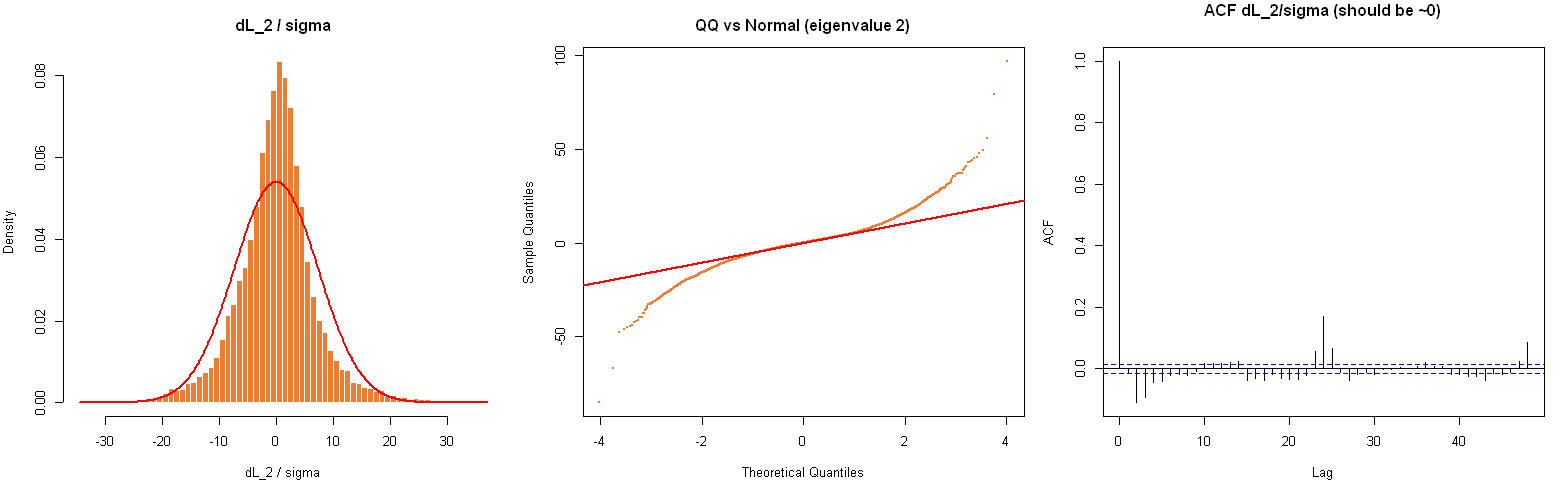

In [25]:
options(repr.plot.width=13, repr.plot.height=4)
par(mfrow=c(1,3), mar=c(4,4,3,1))

xr2 <- quantile(dLt_2, c(0.001, 0.999))
xg2 <- seq(xr2[1], xr2[2], length.out=500)
hist(dLt_2, breaks=200, freq=FALSE, col='#ed7d31', border='white',
     main='dL_2 / sigma', xlab='dL_2 / sigma', xlim=xr2)
lines(xg2, dnorm(xg2, mean(dLt_2), sd(dLt_2)), col='red', lwd=2)

qqnorm(dLt_2, pch=16, cex=0.3, col='#ed7d31', main='QQ vs Normal (eigenvalue 2)')
qqline(dLt_2, col='red', lwd=2)

acf(dLt_2, lag.max=48, main='ACF dL_2/sigma (should be ~0)')
par(mfrow=c(1,1))

Gaussian:  mu=-1.7145e-03  sigma=7.3875e+00  loglik=-59895.63  AIC=119795.26
NIG:  mu=2.5462e-01  delta=5.4450e+00  alpha=1.0056e-01  beta=-4.7287e-03
NIG:  loglik=-58130.93  AIC=116269.86  dAIC(NIG-Gauss)=-3525.41
NIG:  fitted sd=7.3707e+00  fitted skew=-0.1908
Saved: data/levy/price_carma_levy_eigen2.json


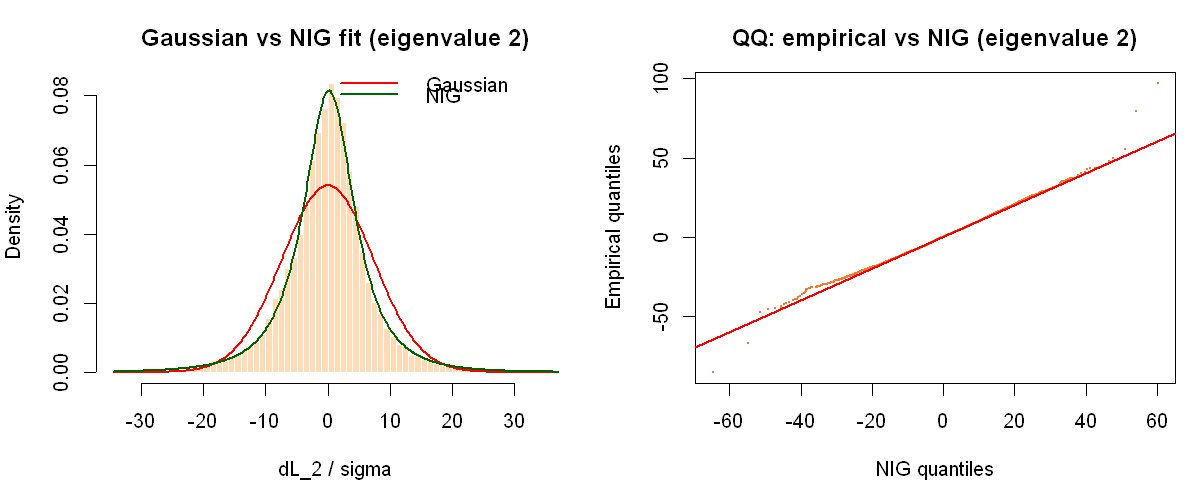

In [26]:
mu_g2  <- mean(dLt_2); sig_g2 <- sd(dLt_2)
ll_g2  <- sum(dnorm(dLt_2, mu_g2, sig_g2, log=TRUE))
aic_g2 <- -2*ll_g2 + 2*2
cat(sprintf('Gaussian:  mu=%.4e  sigma=%.4e  loglik=%.2f  AIC=%.2f\n',
            mu_g2, sig_g2, ll_g2, aic_g2))

nig2   <- nig_fit_fn(dLt_2)
ll_n2  <- nig2$loglik; aic_n2 <- -2*ll_n2 + 2*4
gam_n2 <- sqrt(nig2$alpha^2 - nig2$beta^2)
cat(sprintf('NIG:  mu=%.4e  delta=%.4e  alpha=%.4e  beta=%.4e\n',
            nig2$mu, nig2$delta, nig2$alpha, nig2$beta))
cat(sprintf('NIG:  loglik=%.2f  AIC=%.2f  dAIC(NIG-Gauss)=%.2f\n',
            ll_n2, aic_n2, aic_n2-aic_g2))
cat(sprintf('NIG:  fitted sd=%.4e  fitted skew=%.4f\n',
            sqrt(nig2$delta*nig2$alpha^2/gam_n2^3),
            3*nig2$beta/(nig2$alpha*sqrt(nig2$delta*gam_n2))))

options(repr.plot.width=10, repr.plot.height=4)
xr2 <- quantile(dLt_2, c(0.001, 0.999))
xg2 <- seq(xr2[1], xr2[2], length.out=500)
par(mfrow=c(1,2), mar=c(4,4,3,1))
hist(dLt_2, breaks=200, freq=FALSE, col='#ffdbb8', border='white',
     main='Gaussian vs NIG fit (eigenvalue 2)', xlab='dL_2 / sigma', xlim=xr2)
lines(xg2, dnorm(xg2, mu_g2, sig_g2), col='red', lwd=2)
lines(xg2, exp(log_dnig_fn(xg2, nig2$mu, nig2$delta, nig2$alpha, nig2$beta)),
      col='darkgreen', lwd=2)
legend('topright', c('Gaussian','NIG'), col=c('red','darkgreen'), lwd=2, bty='n')
set.seed(1)
prbs   <- ppoints(length(dLt_2))
q_nig2 <- quantile(rnig_fn(length(dLt_2)*5, nig2$mu, nig2$delta,
                             nig2$alpha, nig2$beta), prbs)
plot(q_nig2, sort(dLt_2), pch=16, cex=0.25, col='#ed7d31',
     main='QQ: empirical vs NIG (eigenvalue 2)',
     xlab='NIG quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)
par(mfrow=c(1,1))

write(toJSON(list(
  eigenvalue_idx = 2L,
  lambda_r       = res_2$lambda_r,
  alpha_r        = res_2$alpha_r,
  sigma          = sigma,
  n_increments   = length(dLt_2),
  dL_true        = as.list(dLt_2),
  gaussian       = list(mu=mu_g2, sigma=sig_g2, loglik=ll_g2, AIC=aic_g2),
  nig            = list(mu=nig2$mu, delta=nig2$delta, alpha=nig2$alpha,
                        beta=nig2$beta, loglik=ll_n2, AIC=aic_n2),
  note = 'dL_true = dL_BDY / sigma. Simulate: X[n] = eAh*X[n-1] + ep*sigma*dL_true_sim'
), auto_unbox=TRUE, digits=15),
'../data/levy/price_carma_levy_eigen2.json')
cat('Saved: data/levy/price_carma_levy_eigen2.json\n')

## 3. Cross-eigenvalue comparison

Standardised distributions `(dL_r/sigma - mean) / sd` for both real eigenvalues overlaid.
In theory both estimators recover the same Lévy driver; differences reflect trapezoid
discretisation error O(h^2 * lambda_r^2), which is larger for eigenvalue 1 (faster).

eigen 1: skew=-0.1645  kurt=10.74
eigen 2: skew=+0.1645  kurt=10.74


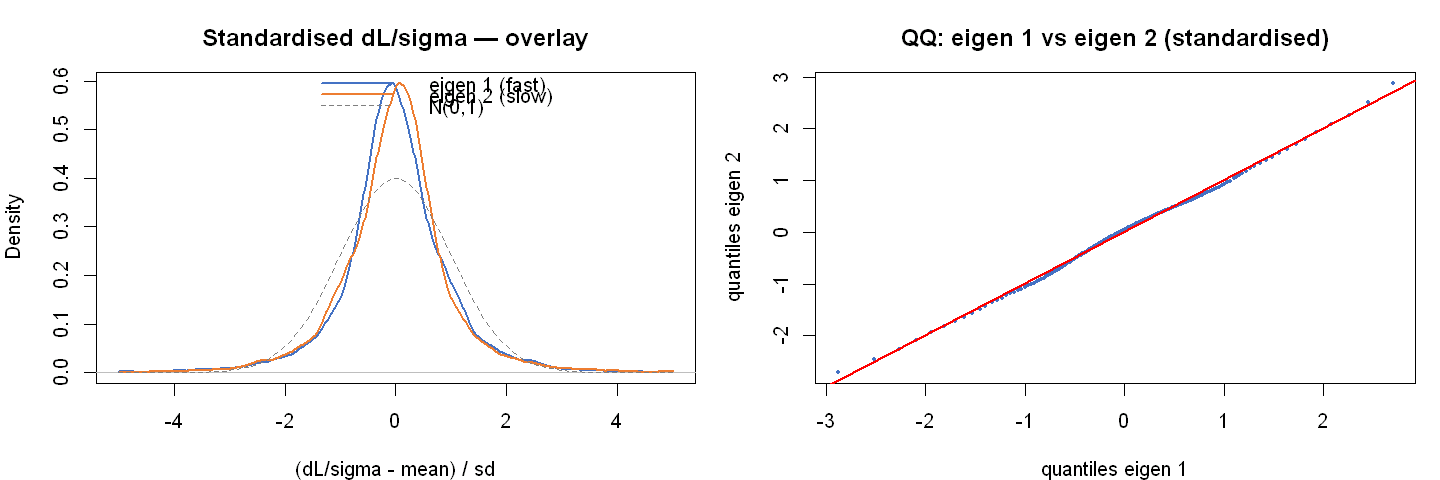

In [27]:
options(repr.plot.width=12, repr.plot.height=4)
par(mfrow=c(1,2), mar=c(4,4,3,1))

z1 <- (dLt_1 - mean(dLt_1)) / sd(dLt_1)
z2 <- (dLt_2 - mean(dLt_2)) / sd(dLt_2)
xr <- range(c(quantile(z1, c(0.001,0.999)), quantile(z2, c(0.001,0.999))))
d1 <- density(z1, from=xr[1], to=xr[2])
d2 <- density(z2, from=xr[1], to=xr[2])
plot(d1, col='#4472c4', lwd=2, main='Standardised dL/sigma — overlay',
     xlab='(dL/sigma - mean) / sd')
lines(d2, col='#ed7d31', lwd=2)
curve(dnorm(x), add=TRUE, col='grey50', lwd=1, lty=2)
legend('topright', c('eigen 1 (fast)','eigen 2 (slow)','N(0,1)'),
       col=c('#4472c4','#ed7d31','grey50'), lwd=c(2,2,1), lty=c(1,1,2), bty='n')

prbs <- seq(0.01, 0.99, by=0.005)
plot(quantile(z1, prbs), quantile(z2, prbs), pch=16, cex=0.5, col='#4472c4',
     main='QQ: eigen 1 vs eigen 2 (standardised)',
     xlab='quantiles eigen 1', ylab='quantiles eigen 2')
abline(0, 1, col='red', lwd=2)
par(mfrow=c(1,1))

cat(sprintf('eigen 1: skew=%+.4f  kurt=%.2f\n',
            mean((dLt_1-mean(dLt_1))^3)/sd(dLt_1)^3,
            mean((dLt_1-mean(dLt_1))^4)/sd(dLt_1)^4))
cat(sprintf('eigen 2: skew=%+.4f  kurt=%.2f\n',
            mean((dLt_2-mean(dLt_2))^3)/sd(dLt_2)^3,
            mean((dLt_2-mean(dLt_2))^4)/sd(dLt_2)^4))

## 4. Validation — CARMA + NIG simulation

Simulate `Y_t = b^T X_t` with the fitted NIG driver for each eigenvalue separately.
Compare marginal distribution and ACF of `Y_sim` vs empirical log-price residuals.

Simulation scheme: `X[n] = eAh * X[n-1] + ep * sigma * dL_true_sim`,  `dL_true_sim ~ NIG(mu, delta, alpha, beta)`.

=== Simulation eigenvalue 1 ===
SD(y)      = 0.028280
SD(Y_sim1) = 0.042139   ratio=1.4901


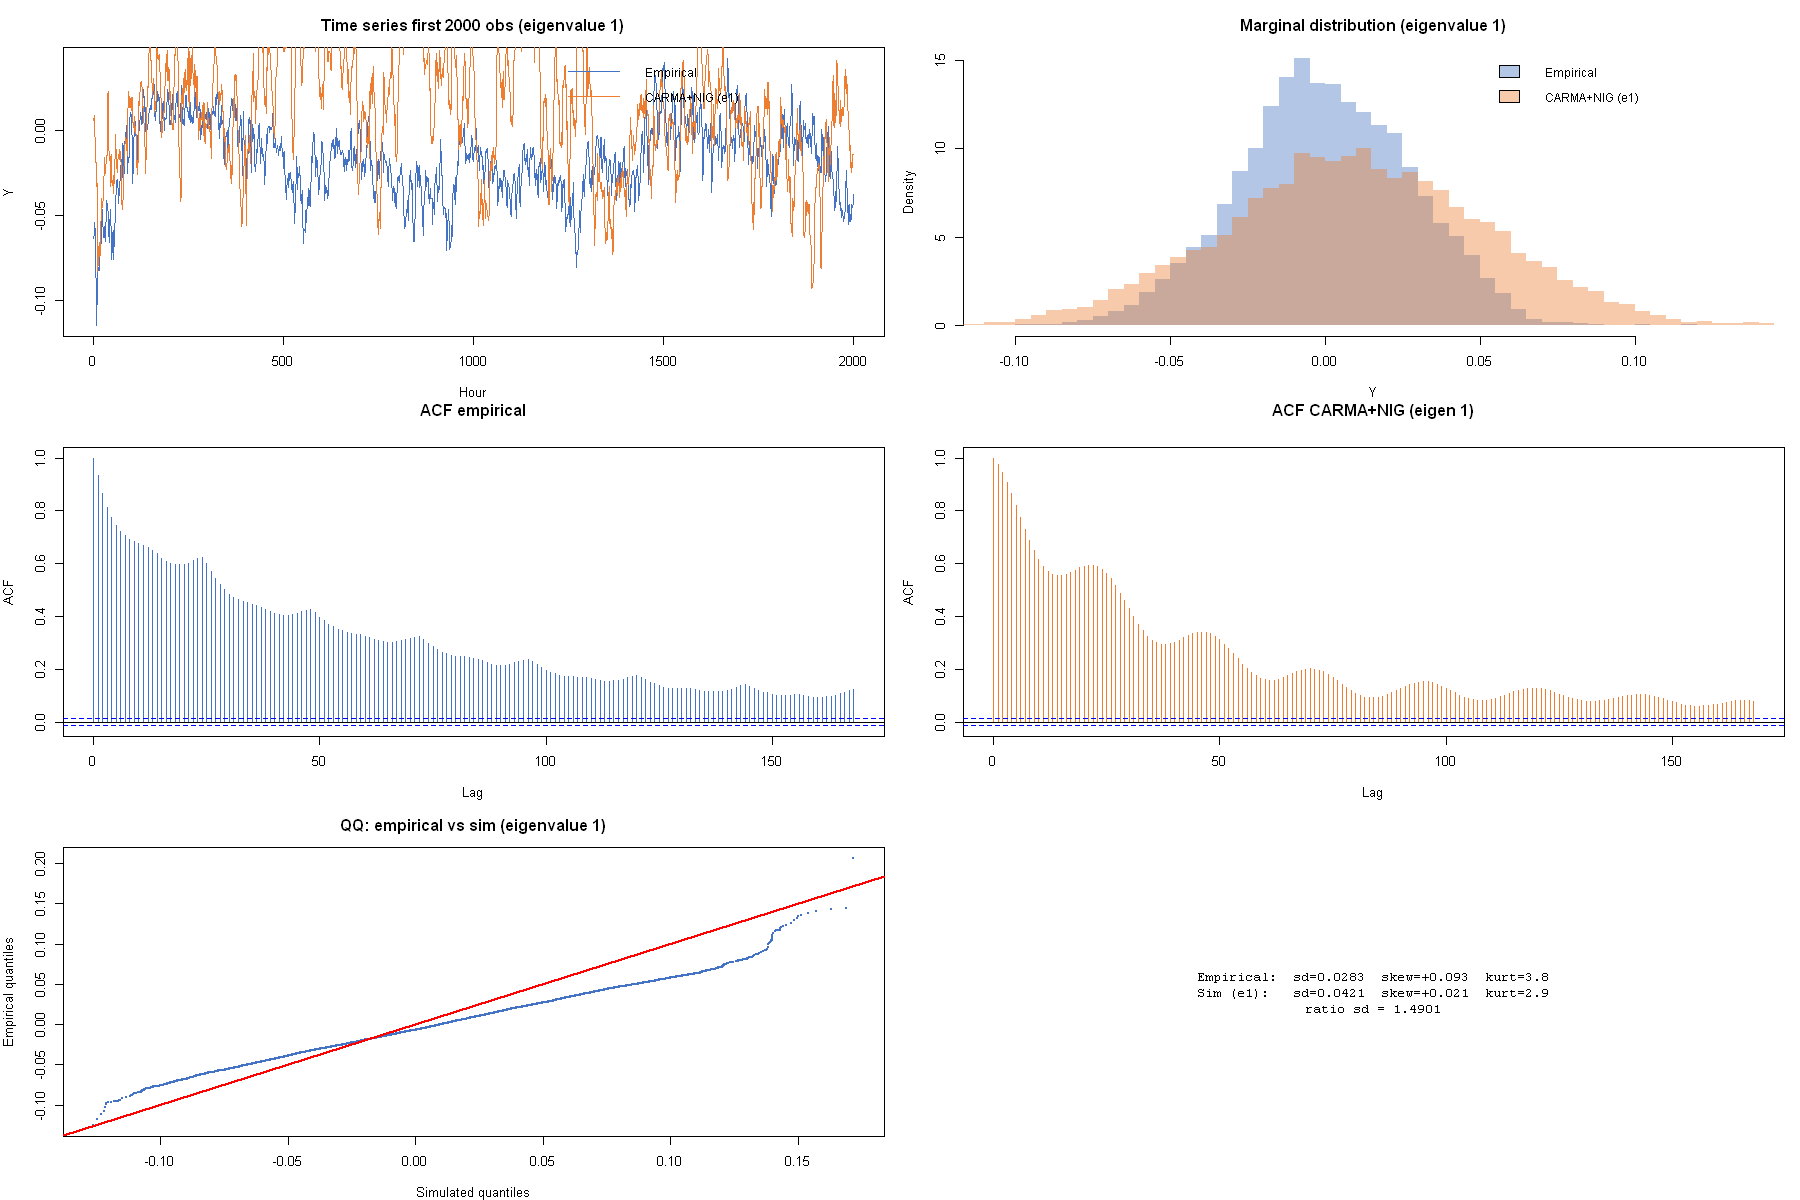

In [62]:
ep_vec   <- rep(0, p); ep_vec[p] <- 1.0
n_burnin <- 2000

dLt_sim1 <- rnig_fn(n + n_burnin, nig1$mu, nig1$delta, nig1$alpha, nig1$beta)
X_cur <- rep(0, p)
Y_sim1 <- numeric(n + n_burnin)
for (i in seq_len(n + n_burnin)) {
  X_cur     <- as.numeric(eAh %*% X_cur) + ep_vec * sigma * dLt_sim1[i]
  Y_sim1[i] <- sum(b_pen * X_cur)
}
Y_sim1 <- Y_sim1[(n_burnin+1):(n+n_burnin)]

cat(sprintf('=== Simulation eigenvalue 1 ===\n'))
cat(sprintf('SD(y)      = %.6f\n', sd(y)))
cat(sprintf('SD(Y_sim1) = %.6f   ratio=%.4f\n', sd(Y_sim1), sd(Y_sim1)/sd(y)))

options(repr.plot.width=15, repr.plot.height=10)
par(mfrow=c(3,2), mar=c(4,4,3,1))

plot(1:2000, y[1:2000], type='l', col='#4472c4', lwd=0.8,
     main='Time series first 2000 obs (eigenvalue 1)', xlab='Hour', ylab='Y')
lines(1:2000, Y_sim1[1:2000], col='#ed7d31', lwd=0.8)
legend('topright', c('Empirical','CARMA+NIG (e1)'),
       col=c('#4472c4','#ed7d31'), lwd=1.5, bty='n', cex=0.9)

xr <- quantile(c(y, Y_sim1), c(0.001, 0.999))
hist(y,      breaks=100, freq=FALSE, col=rgb(0.27,0.45,0.76,0.4), border=NA,
     main='Marginal distribution (eigenvalue 1)', xlab='Y', xlim=xr)
hist(Y_sim1, breaks=100, freq=FALSE, col=rgb(0.93,0.49,0.19,0.4), border=NA, add=TRUE)
legend('topright', c('Empirical','CARMA+NIG (e1)'),
       fill=c(rgb(0.27,0.45,0.76,0.4), rgb(0.93,0.49,0.19,0.4)), bty='n', cex=0.9)

acf(y,      lag.max=168, main='ACF empirical',            col='#4472c4')
acf(Y_sim1, lag.max=168, main='ACF CARMA+NIG (eigen 1)',  col='#ed7d31')

prbs <- ppoints(min(length(y), length(Y_sim1)))
plot(quantile(Y_sim1, prbs), quantile(y, prbs), pch=16, cex=0.25, col='#4472c4',
     main='QQ: empirical vs sim (eigenvalue 1)',
     xlab='Simulated quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)

plot.new()
text(0.5, 0.5, sprintf(
  'Empirical:  sd=%.4f  skew=%+.3f  kurt=%.1f\nSim (e1):   sd=%.4f  skew=%+.3f  kurt=%.1f\nratio sd = %.4f',
  sd(y), mean((y-mean(y))^3)/sd(y)^3, mean((y-mean(y))^4)/sd(y)^4,
  sd(Y_sim1), mean((Y_sim1-mean(Y_sim1))^3)/sd(Y_sim1)^3,
  mean((Y_sim1-mean(Y_sim1))^4)/sd(Y_sim1)^4,
  sd(Y_sim1)/sd(y)), cex=1.0, family='mono')
par(mfrow=c(1,1))


=== Simulation eigenvalue 2 ===
SD(y)      = 0.028280
SD(Y_sim2) = 0.211986   ratio=7.4960


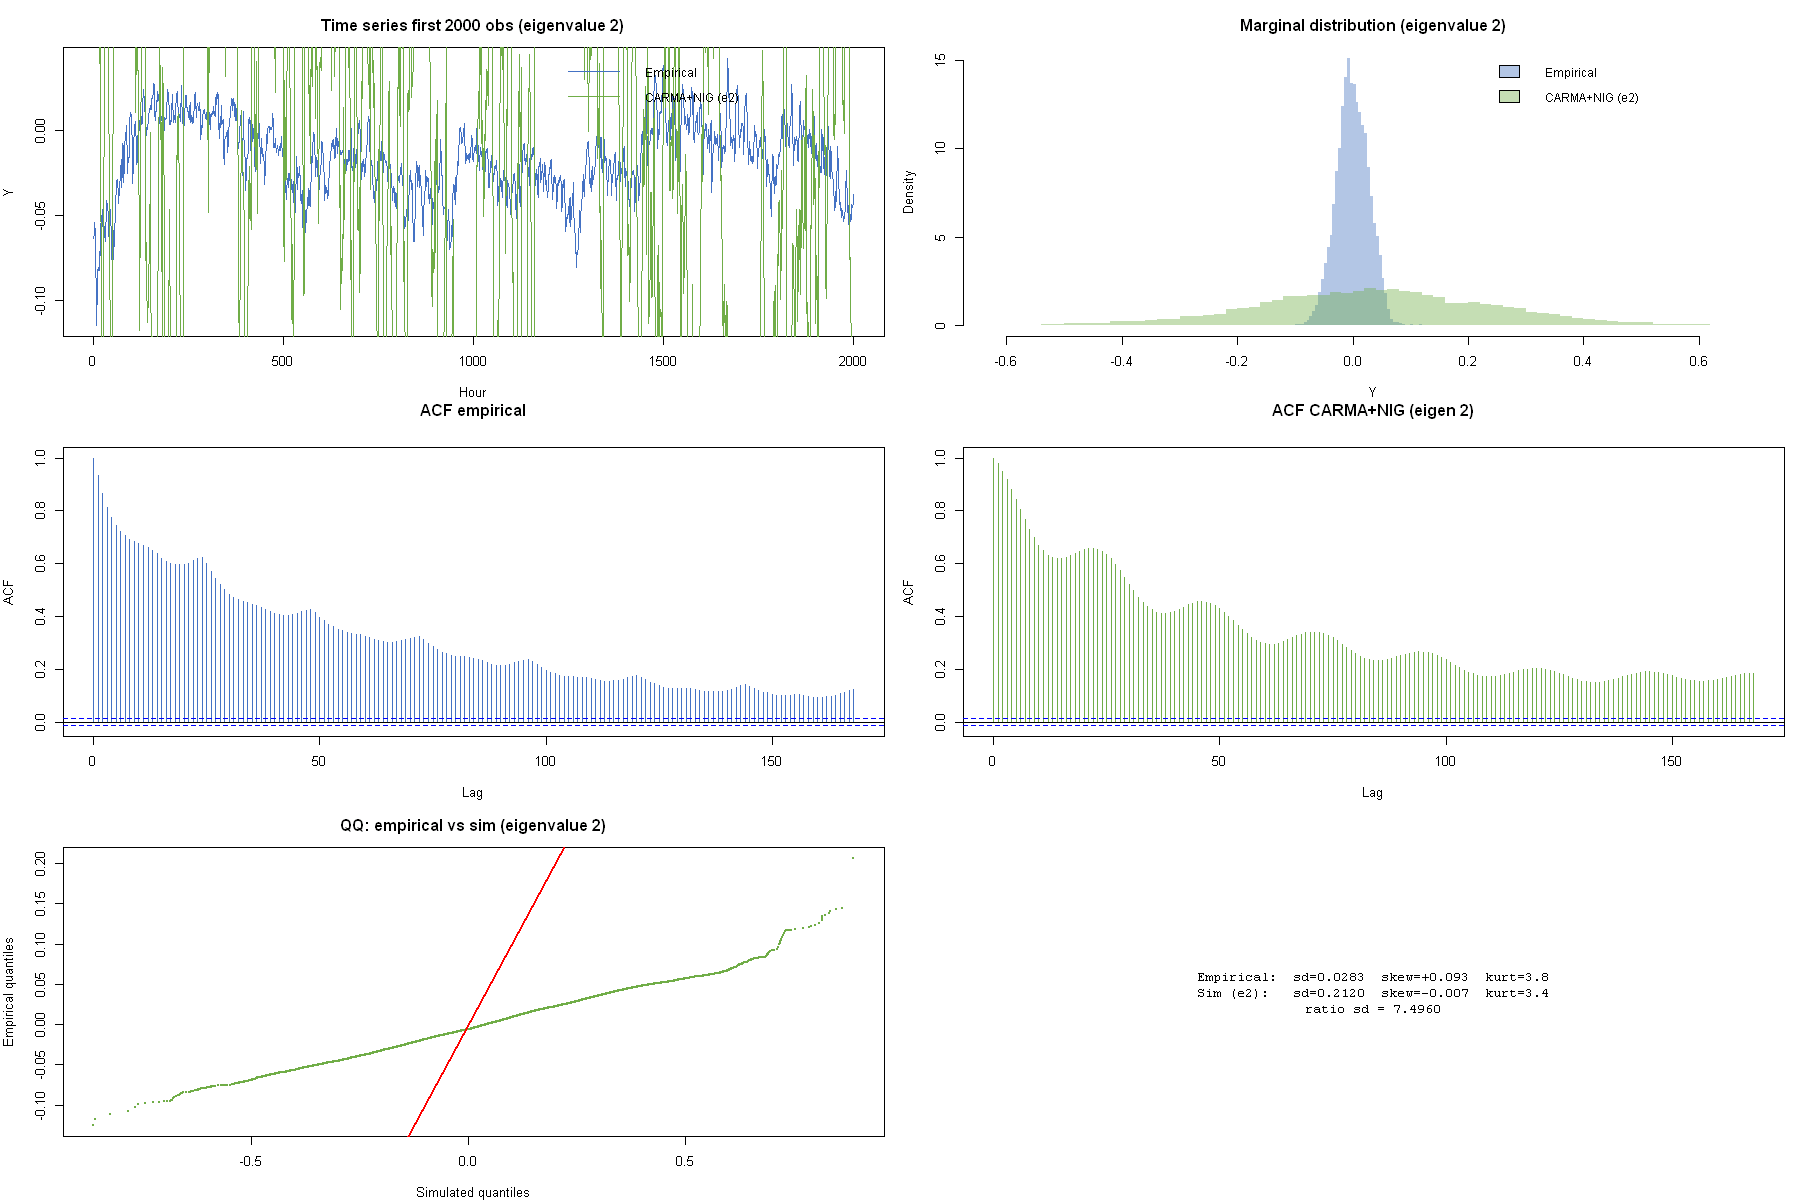

In [29]:
set.seed(43)
ep_vec   <- rep(0, p); ep_vec[p] <- 1.0
n_burnin <- 2000

dLt_sim2 <- rnig_fn(n + n_burnin, nig2$mu, nig2$delta, nig2$alpha, nig2$beta)
X_cur <- rep(0, p)
Y_sim2 <- numeric(n + n_burnin)
for (i in seq_len(n + n_burnin)) {
  X_cur     <- as.numeric(eAh %*% X_cur) + ep_vec * sigma * dLt_sim2[i]
  Y_sim2[i] <- sum(b_pen * X_cur)
}
Y_sim2 <- Y_sim2[(n_burnin+1):(n+n_burnin)]

cat(sprintf('=== Simulation eigenvalue 2 ===\n'))
cat(sprintf('SD(y)      = %.6f\n', sd(y)))
cat(sprintf('SD(Y_sim2) = %.6f   ratio=%.4f\n', sd(Y_sim2), sd(Y_sim2)/sd(y)))

options(repr.plot.width=15, repr.plot.height=10)
par(mfrow=c(3,2), mar=c(4,4,3,1))

plot(1:2000, y[1:2000], type='l', col='#4472c4', lwd=0.8,
     main='Time series first 2000 obs (eigenvalue 2)', xlab='Hour', ylab='Y')
lines(1:2000, Y_sim2[1:2000], col='#70ad47', lwd=0.8)
legend('topright', c('Empirical','CARMA+NIG (e2)'),
       col=c('#4472c4','#70ad47'), lwd=1.5, bty='n', cex=0.9)

xr <- quantile(c(y, Y_sim2), c(0.001, 0.999))
hist(y,      breaks=100, freq=FALSE, col=rgb(0.27,0.45,0.76,0.4), border=NA,
     main='Marginal distribution (eigenvalue 2)', xlab='Y', xlim=xr)
hist(Y_sim2, breaks=100, freq=FALSE, col=rgb(0.44,0.68,0.28,0.4), border=NA, add=TRUE)
legend('topright', c('Empirical','CARMA+NIG (e2)'),
       fill=c(rgb(0.27,0.45,0.76,0.4), rgb(0.44,0.68,0.28,0.4)), bty='n', cex=0.9)

acf(y,      lag.max=168, main='ACF empirical',            col='#4472c4')
acf(Y_sim2, lag.max=168, main='ACF CARMA+NIG (eigen 2)',  col='#70ad47')

prbs <- ppoints(min(length(y), length(Y_sim2)))
plot(quantile(Y_sim2, prbs), quantile(y, prbs), pch=16, cex=0.25, col='#70ad47',
     main='QQ: empirical vs sim (eigenvalue 2)',
     xlab='Simulated quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)

plot.new()
text(0.5, 0.5, sprintf(
  'Empirical:  sd=%.4f  skew=%+.3f  kurt=%.1f\nSim (e2):   sd=%.4f  skew=%+.3f  kurt=%.1f\nratio sd = %.4f',
  sd(y), mean((y-mean(y))^3)/sd(y)^3, mean((y-mean(y))^4)/sd(y)^4,
  sd(Y_sim2), mean((Y_sim2-mean(Y_sim2))^3)/sd(Y_sim2)^3,
  mean((Y_sim2-mean(Y_sim2))^4)/sd(Y_sim2)^4,
  sd(Y_sim2)/sd(y)), cex=1.0, family='mono')
par(mfrow=c(1,1))

In [83]:
q  <- p - 1; bp <- b_pen[p]
B_tilde      <- matrix(0, q, q)
for (i in seq_len(q-1)) B_tilde[i, i+1] <- 1.0
B_tilde[q, ] <- -b_pen[1:q] / bp
e_tilde      <- rep(0, q); e_tilde[q] <- 1.0 / bp
eBh_tilde    <- expm(B_tilde * h)
eBh_e        <- as.numeric(eBh_tilde %*% e_tilde)

X_q <- matrix(0, n, q)
for (i in 2:n)
  X_q[i, ] <- as.numeric(eBh_tilde %*% X_q[i-1,]) +
               (h/2) * (eBh_e * y[i-1] + e_tilde * y[i])
X_direct <- cbind(X_q, (y - X_q %*% b_pen[1:q]) / bp)
cat(sprintf('Max |y - b^T X_direct| = %.2e\n', max(abs(y - X_direct %*% b_pen))))

bdy_recover_direct <- function(which_real) {
  lam       <- re_lam[which_real]
  idx       <- which(abs(Im(ev_fix$values)) < 1e-6 &
                     abs(Re(ev_fix$values) - lam) < 1e-8)[1]
  Vinv_ep_r <- Re(Rinv_fix[idx, p])          # [V^{-1} ep]_r  exact, indep. de normalisation
  z         <- Re(Rinv_fix[idx, ] %*% t(X_direct))
  dL        <- (z[2:n] - exp(lam * h) * z[1:(n-1)]) / Vinv_ep_r
  dL[is.finite(dL)]
}

n_burn <- 2000
tmp <- bdy_recover_direct(1); dL_d1 <- tmp[(n_burn+1):length(tmp)]
tmp <- bdy_recover_direct(2); dL_d2 <- tmp[(n_burn+1):length(tmp)]

for (tag in c('eigen1','eigen2')) {
  dL <- if (tag=='eigen1') dL_d1 else dL_d2
  cat(sprintf('%s:  N=%d  SD=%.4e  skew=%+.3f  kurt=%.2f\n',
    tag, length(dL), sd(dL),
    mean((dL-mean(dL))^3)/sd(dL)^3,
    mean((dL-mean(dL))^4)/sd(dL)^4))
}


Max |y - b^T X_direct| = 1.39e-17
eigen1:  N=15520  SD=7.0746e-07  skew=+0.143  kurt=10.42
eigen2:  N=15520  SD=7.1632e-07  skew=+0.143  kurt=10.42


Warning message in xy.coords(x, y, xlabel, ylabel, log):
"8 y values <= 0 omitted from logarithmic plot"
Warning message in xy.coords(x, y, xlabel, ylabel, log):
"10 y values <= 0 omitted from logarithmic plot"


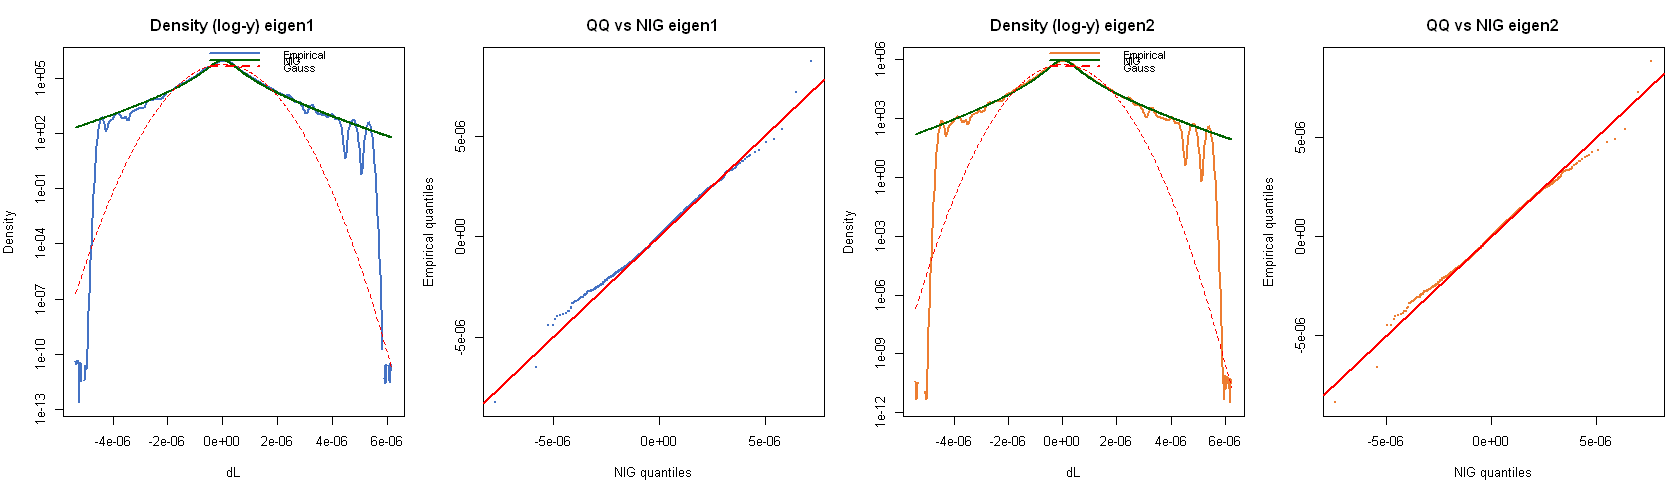

In [84]:
options(repr.plot.width=14, repr.plot.height=4)
par(mfrow=c(1,4), mar=c(4,4,3,1))

for (tag in c('eigen1','eigen2')) {
  dL <- if (tag=='eigen1') dL_d1 else dL_d2
  ng <- if (tag=='eigen1') nig_d1 else nig_d2
  cl <- if (tag=='eigen1') '#4472c4' else '#ed7d31'

  xr  <- quantile(dL, c(0.0001, 0.9999))
  xg  <- seq(xr[1], xr[2], length.out=500)
  d_nig  <- exp(log_dnig_fn(xg, ng$mu, ng$delta, ng$alpha, ng$beta))
  d_norm <- dnorm(xg, mean(dL), sd(dL))
  d_emp  <- density(dL, from=xr[1], to=xr[2], n=512)

  plot(d_emp, col=cl, lwd=2, log='y', xlim=xr,
       main=paste('Density (log-y)', tag), xlab='dL')
  lines(xg, d_nig,  col='darkgreen', lwd=2)
  lines(xg, d_norm, col='red', lwd=1.5, lty=2)
  legend('topright', c('Empirical','NIG','Gauss'),
         col=c(cl,'darkgreen','red'), lwd=2, lty=c(1,1,2), bty='n', cex=0.8)

  set.seed(1)
  prbs  <- ppoints(length(dL))
  q_nig <- quantile(rnig_fn(length(dL)*5, ng$mu, ng$delta, ng$alpha, ng$beta), prbs)
  plot(q_nig, sort(dL), pch=16, cex=0.2, col=cl,
       main=paste('QQ vs NIG', tag),
       xlab='NIG quantiles', ylab='Empirical quantiles')
  abline(0, 1, col='red', lwd=2)
}
par(mfrow=c(1,1))


SD(y)      = 0.028280
SD(Y_sim2) = 0.053320   ratio = 1.8854


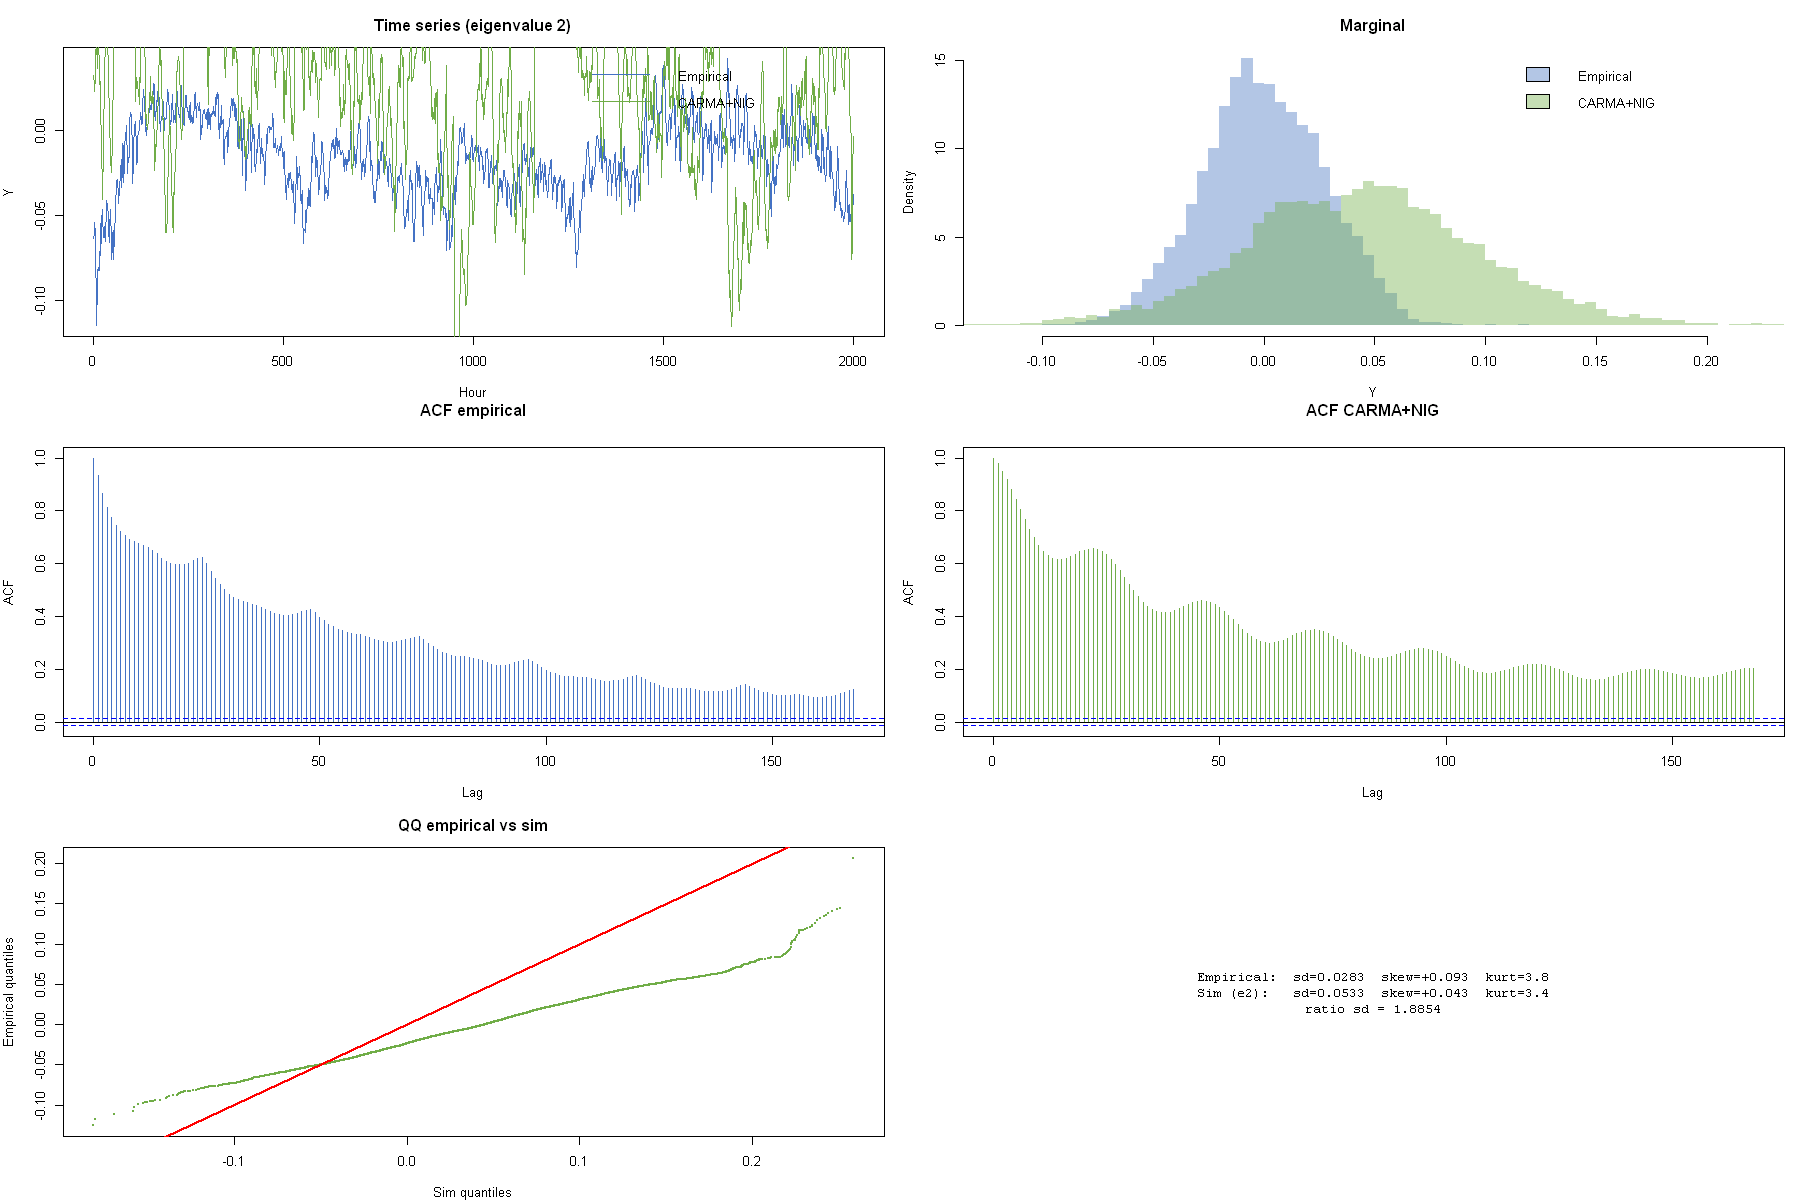

In [85]:
set.seed(43)
ep_vec   <- rep(0, p); ep_vec[p] <- 1.0
n_burnin <- 2000

dL_sim2 <- rnig_fn(n + n_burnin, nig_d2$mu, nig_d2$delta, nig_d2$alpha, nig_d2$beta)
X_cur   <- rep(0, p)
Y_sim2  <- numeric(n + n_burnin)
for (i in seq_len(n + n_burnin)) {
  X_cur     <- as.numeric(eAh %*% X_cur) + ep_vec * dL_sim2[i]
  Y_sim2[i] <- sum(b_pen * X_cur)
}
Y_sim2 <- Y_sim2[(n_burnin+1):(n+n_burnin)]

cat(sprintf('SD(y)      = %.6f\n', sd(y)))
cat(sprintf('SD(Y_sim2) = %.6f   ratio = %.4f\n', sd(Y_sim2), sd(Y_sim2)/sd(y)))

options(repr.plot.width=15, repr.plot.height=10)
par(mfrow=c(3,2), mar=c(4,4,3,1))

plot(1:2000, y[1:2000], type='l', col='#4472c4', lwd=0.8,
     main='Time series (eigenvalue 2)', xlab='Hour', ylab='Y')
lines(1:2000, Y_sim2[1:2000], col='#70ad47', lwd=0.8)
legend('topright', c('Empirical','CARMA+NIG'), col=c('#4472c4','#70ad47'), lwd=1.5, bty='n')

xr <- quantile(c(y, Y_sim2), c(0.001, 0.999))
hist(y,      breaks=100, freq=FALSE, col=rgb(0.27,0.45,0.76,0.4), border=NA,
     main='Marginal', xlab='Y', xlim=xr)
hist(Y_sim2, breaks=100, freq=FALSE, col=rgb(0.44,0.68,0.28,0.4), border=NA, add=TRUE)
legend('topright', c('Empirical','CARMA+NIG'),
       fill=c(rgb(0.27,0.45,0.76,0.4), rgb(0.44,0.68,0.28,0.4)), bty='n')

acf(y,      lag.max=168, main='ACF empirical', col='#4472c4')
acf(Y_sim2, lag.max=168, main='ACF CARMA+NIG', col='#70ad47')

prbs <- ppoints(min(length(y), length(Y_sim2)))
plot(quantile(Y_sim2, prbs), quantile(y, prbs), pch=16, cex=0.25, col='#70ad47',
     main='QQ empirical vs sim', xlab='Sim quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)

plot.new()
text(0.5, 0.5, sprintf(
  'Empirical:  sd=%.4f  skew=%+.3f  kurt=%.1f\nSim (e2):   sd=%.4f  skew=%+.3f  kurt=%.1f\nratio sd = %.4f',
  sd(y),      mean((y-mean(y))^3)/sd(y)^3,           mean((y-mean(y))^4)/sd(y)^4,
  sd(Y_sim2), mean((Y_sim2-mean(Y_sim2))^3)/sd(Y_sim2)^3, mean((Y_sim2-mean(Y_sim2))^4)/sd(Y_sim2)^4,
  sd(Y_sim2)/sd(y)), cex=1.0, family='mono')
par(mfrow=c(1,1))


SD(y)      = 0.028280
SD(Y_sim1) = 0.049677   ratio = 1.7566


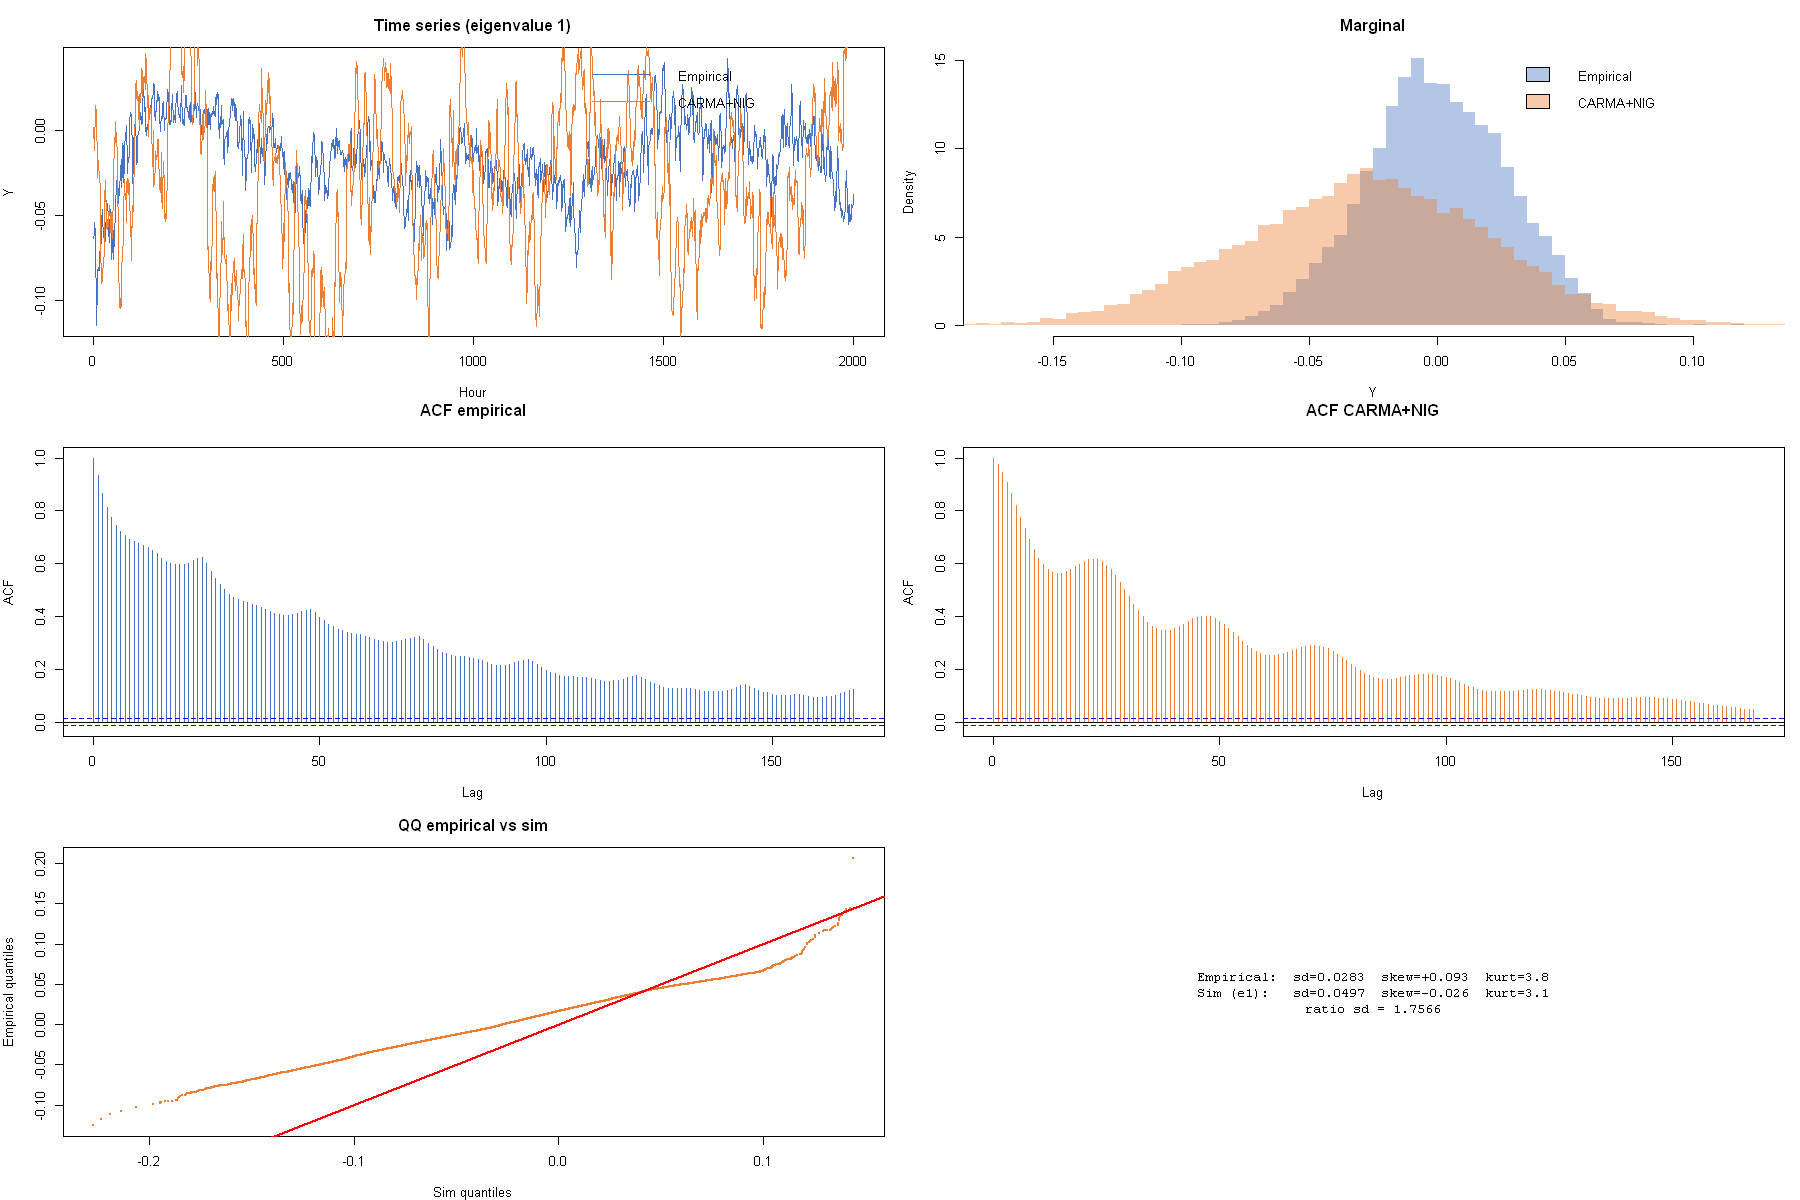

In [86]:
set.seed(42)
ep_vec   <- rep(0, p); ep_vec[p] <- 1.0
n_burnin <- 2000

dL_sim1 <- rnig_fn(n + n_burnin, nig_d1$mu, nig_d1$delta, nig_d1$alpha, nig_d1$beta)
X_cur   <- rep(0, p)
Y_sim1  <- numeric(n + n_burnin)
for (i in seq_len(n + n_burnin)) {
  X_cur     <- as.numeric(eAh %*% X_cur) + ep_vec * dL_sim1[i]
  Y_sim1[i] <- sum(b_pen * X_cur)
}
Y_sim1 <- Y_sim1[(n_burnin+1):(n+n_burnin)]

cat(sprintf('SD(y)      = %.6f\n', sd(y)))
cat(sprintf('SD(Y_sim1) = %.6f   ratio = %.4f\n', sd(Y_sim1), sd(Y_sim1)/sd(y)))

options(repr.plot.width=15, repr.plot.height=10)
par(mfrow=c(3,2), mar=c(4,4,3,1))

plot(1:2000, y[1:2000], type='l', col='#4472c4', lwd=0.8,
     main='Time series (eigenvalue 1)', xlab='Hour', ylab='Y')
lines(1:2000, Y_sim1[1:2000], col='#ed7d31', lwd=0.8)
legend('topright', c('Empirical','CARMA+NIG'), col=c('#4472c4','#ed7d31'), lwd=1.5, bty='n')

xr <- quantile(c(y, Y_sim1), c(0.001, 0.999))
hist(y,      breaks=100, freq=FALSE, col=rgb(0.27,0.45,0.76,0.4), border=NA,
     main='Marginal', xlab='Y', xlim=xr)
hist(Y_sim1, breaks=100, freq=FALSE, col=rgb(0.93,0.49,0.19,0.4), border=NA, add=TRUE)
legend('topright', c('Empirical','CARMA+NIG'),
       fill=c(rgb(0.27,0.45,0.76,0.4), rgb(0.93,0.49,0.19,0.4)), bty='n')

acf(y,      lag.max=168, main='ACF empirical', col='#4472c4')
acf(Y_sim1, lag.max=168, main='ACF CARMA+NIG', col='#ed7d31')

prbs <- ppoints(min(length(y), length(Y_sim1)))
plot(quantile(Y_sim1, prbs), quantile(y, prbs), pch=16, cex=0.25, col='#ed7d31',
     main='QQ empirical vs sim', xlab='Sim quantiles', ylab='Empirical quantiles')
abline(0, 1, col='red', lwd=2)

plot.new()
text(0.5, 0.5, sprintf(
  'Empirical:  sd=%.4f  skew=%+.3f  kurt=%.1f\nSim (e1):   sd=%.4f  skew=%+.3f  kurt=%.1f\nratio sd = %.4f',
  sd(y),      mean((y-mean(y))^3)/sd(y)^3,           mean((y-mean(y))^4)/sd(y)^4,
  sd(Y_sim1), mean((Y_sim1-mean(Y_sim1))^3)/sd(Y_sim1)^3, mean((Y_sim1-mean(Y_sim1))^4)/sd(Y_sim1)^4,
  sd(Y_sim1)/sd(y)), cex=1.0, family='mono')
par(mfrow=c(1,1))
